## Goal of this

- create a 2x2 budget with the time snaps in the miniASTE
- create a Barents Sea budget with the snaps and explain the difference between the ADVh term and the M gates

In [2]:
# auto-reload edited modules
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, "/home/mmurakami/crios_backups/an_helper_functions")

# run the script into the curre nt kernel (vars/functions become available)
%run -i "/home/mmurakami/crios_backups/an_helper_functions/prep_grid_aste_90.py"

(450, 90)
RAC2d (40500,)
(100,)


In [3]:
# we need to load the miniaste
dirroot = "/scratch3/atnguyen/aste_90x150x60/"
dirgrid = dirroot + "GRID_real8/"
dirgridnb = dirroot + "GRID_noblank/"
runstr= "run_c68v_heffmosm3x_layers_lessmem1_viscAHp5em2_it0000_pk0000000001/"
layers_path = dirroot + runstr
extL = "LAYERS"
dirmask = dirroot + "run_template/input_maskTransport/"
dirbudg = layers_path + "diags/BUDG/"
dirdiags = dirbudg
dirstate = layers_path + "diags/STATE/"
dirlayers = layers_path + "diags/LAYERS/"
dirtrsp = layers_path + "diags/TRSP/"

In [4]:
# try to use rdmds
fileprefix = "/scratch3/atnguyen/aste_90x150x60/"
extBasin='run_template/input_maskTransport/'
filename = fileprefix + extBasin + "GATE_transports_v2_mskBasin.bin"
ind = np.fromfile(filename, dtype=np.int32)  # auto-reads .meta for shape/dtype/order
orig_shape = (ind.shape)

ind2d = ind.reshape(ny,nx)

mymsk = np.full((ny,nx),np.nan)
mymsk[ind2d == 57408.0] = 1

# make this smaller
mymsk[:,27:50] = np.nan
mymsk[:160,12:30] = np.nan
mymsk[160:163,15:30] = np.nan

ind = ind.reshape(ny,nx)
mymsk = np.full((ny,nx),np.nan)
mymsk[ind == 57408.0] = 1

# make this smaller
mymsk[:,27:50] = np.nan
mymsk[:160,12:30] = np.nan
mymsk[160:163,15:30] = np.nan

In [5]:
# plt.pcolormesh(mymsk)
# plt.ylim(150,180)

In [6]:
# load the ADV terms for the Barents Sea for this singular box -- single box will all be contributing the same
# to the same T or S bin, so these will be the same when plotted in T or S space
# but we can show this anyways
tsstr = np.array(["0000000002","0000000003"])
t2 = int(tsstr[1]) # for the offline version

In [7]:
# load the TS bins
# also load the bins again so we have them locally
boundsT = np.round(np.squeeze(rdmds(layers_path + "layers2TH")).ravel(),1)
nT = boundsT.size - 1
boundsS = np.round(np.squeeze(rdmds(layers_path + "layers1SLT")).ravel(),1)
nS = boundsS.size - 1
binwidthT = boundsT[1:] - boundsT[:-1]
binwidthS = boundsS[1:] - boundsS[:-1]
binwidthT1 = 0.5 * (binwidthT[1:] + binwidthT[:-1])  # normalize by these
binwidthS1 = 0.5 * (binwidthS[1:] + binwidthS[:-1])
binmidT = (boundsT[1:] + boundsT[:-1]) /2    # bin to these
binmidS = (boundsS[1:] + boundsS[:-1]) /2
nT = nT
nS = nS
nTm1 = nT-1
nSm1 = nS-1

## Load the diagnostics and have them in the correct shape in general

In [8]:
dt = 1800

In [9]:
t2 = int(tsstr[1])
# 'diags/state_3d_set1'
# read theta and salt averages from the t2 timestep (average)
file_name = "state_3d_set1"
meta_state_3d_set1 = parsemeta(dirstate + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_state_3d_set1["fldList"])
varnames = np.array(["THETA","SALT"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
THETA,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[0])
SALT,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[1])

THETA = THETA.reshape(nz,ny,nx)
SALT = SALT.reshape(nz,ny,nx)

In [10]:
# read the ADVx term -- also create the ADVhT term for this region where we can multiply by mask for later

file_name = "budg3d_hflux_set2"
meta_budg3d_hflux_set2 = parsemeta(dirdiags + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_budg3d_hflux_set2["fldList"])
varnames = np.array(["ADVx_TH","ADVy_TH"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
ADVx_TH,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[0])
ADVy_TH,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[1])


ADV_hconv = calc_UV_conv_mod(nfx, nfy,get_aste_faces(ADVx_TH.reshape(nz, ny, nx), nfx, nfy),get_aste_faces(ADVy_TH.reshape(nz, ny, nx), nfx, nfy))
ADV_hconv = ADV_hconv #* hf   # degC·m^3/s at cell centers (matches: ff.DFh = ff.DFh .* hf)
ADVhT = ADV_hconv

In [11]:
# create the gate terms and prove the same figure as in the 1/20 meeting


def _mark_points(mask, xs, ys, code, ny, nx, name="gate"):
    """
    Mark (y, x) points in mask with 'code'.
    If a point already has a different non-NaN code, set it to 3 (overlap).
    Bounds are clipped to the grid silently.
    """
    xs = np.asarray(xs)
    ys = np.asarray(ys)

    if xs.shape != ys.shape:
        raise ValueError(f"{name}: x/y length mismatch: {xs.shape} vs {ys.shape}")

    # clip to valid indices just in case
    xi = np.clip(xs.astype(int), 0, nx-1)
    yi = np.clip(ys.astype(int), 0, ny-1)

    for j, i in zip(yi, xi):
        cur = mask[j, i]
        if np.isnan(cur):
            mask[j, i] = code
        elif cur == code or cur == 3:
            # already same code or already overlap — leave as is
            continue
        else:
            mask[j, i] = 3  # overlap with different code
    return mask

# these are the indices we want to read from, but not write to
# at y = 186, we want -ADVy
x_bsoh = np.array([54, 54, 54, 54, 54])
x_bsov = np.array([0,  1,  2,  3,  4,  5,  6,  7,  8,  9])    # from Norway to Sp
y_bsoh = np.array([145, 146, 147, 148, 149])
y_bsov = np.array([186, 186, 186, 186, 186, 186, 186, 186, 186, 186])    # from Norway to Sp

x_spfjh = np.array([20,20,20,23,24,24,26,26])    # vertical gates from Sp to Fj as -x
y_spfjh = np.array([185,184,183,182,181,180,179,178])
x_spfjv = np.array([20,21,22,23,24,25,26])          # horizontal gates where we want to read -y
y_spfjv = np.array([183,183,183,183,182,180,180])

y_fjnzv = np.arange(165,175,1)
x_fjnzv = np.full_like(y_fjnzv,27)    # horizontal gate where we want to read -x

y_nzruv = np.arange(152,155,1)
x_nzruv = np.full_like(y_nzruv,12)   # horizontal gate where we want to read -x

# gates_mask starts as NaN everywhere
gates_mask = np.full((ny, nx), np.nan, dtype=float)

# ---- mark H gates with code = 1 ----
gates_mask = _mark_points(gates_mask, x_bsoh, y_bsoh, 1, ny, nx, name="bsoh")
gates_mask = _mark_points(gates_mask, x_spfjh, y_spfjh, 1, ny, nx, name="spfjh")

# ---- mark V gates with code = 2 ----
gates_mask = _mark_points(gates_mask, x_bsov,  y_bsov,  2, ny, nx, name="bsov")
gates_mask = _mark_points(gates_mask, x_spfjv, y_spfjv, 2, ny, nx, name="spfjv")
gates_mask = _mark_points(gates_mask, x_fjnzv, y_fjnzv, 1, ny, nx, name="fjnzv")
gates_mask = _mark_points(gates_mask, x_nzruv, y_nzruv, 1, ny, nx, name="nzruv")

# Optional: if you prefer 0 instead of NaN for “not a gate”
# gates_mask = np.nan_to_num(gates_mask, nan=0.0)

# let's make a mask of these to double check that we did this correctly
gates_mask[182,23] = 3
gates_mask[180,24] = 3 
gates_mask[180,26] = np.nan
gates_mask[182,24] = np.nan
gates_mask[183,23] = np.nan


testmsk = gates_mask.copy()
testmsk[:,:19] = np.nan
testmsk[:,30:] = np.nan
testmsk[:178,:] = np.nan
y_spfjv2,x_spfjv2 = np.where(testmsk == 2)[0],np.where(testmsk == 2)[1]
y_spfjh2,x_spfjh2 = np.where(testmsk == 1)[0],np.where(testmsk == 1)[1]
y_spfjb2,x_spfjb2 = np.where(testmsk == 3)[0],np.where(testmsk == 3)[1]
RAC = mygrid['RAC']

In [12]:
# look at the function in create_aste90_layers to see what we're looking for
# we used create_layers_totalTHETA in verify_gates_aste90 to prove closure
print(np.nansum(ADVhT * np.tile(mymsk[np.newaxis,:,:],(nz,1,1))))   # degC.m^3/s
# this is the number we're trying to match with the gates
ADVhT_BS = ADVhT * np.tile(mymsk[np.newaxis,:,:],(nz,1,1))

10512990.032651436


In [13]:
def _bincount_sum_with_nan(idx, vals, nout):
    """
    NaN-aware per-bin sum:
    if *all* entries in a bin are NaN, that bin returns NaN;
    otherwise NaNs are ignored and finite values are summed.
    """
    # track counts of non-nan contributions
    finite = np.isfinite(vals)
    sums   = np.bincount(idx[finite], vals[finite], minlength=nout).astype(float)
    counts = np.bincount(idx[finite], None, minlength=nout).astype(float)
    out = sums
    out[counts == 0] = np.nan
    return out

In [14]:
# --- "new" interpretation: bin by binmidT intervals ---
theta_flat = THETA.ravel()
salt_flat = SALT.ravel()
ADVh_flat   = ADVhT_BS.ravel()
# ADVr_flat   = ADVrT_BS.ravel()

# binmidT[i] <= THETA < binmidT[i+1], i=0..nT-2
bin_idx_mid = np.digitize(theta_flat, binmidT, right=False) - 1
valid_mid   = (bin_idx_mid >= 0) & (bin_idx_mid < nTm1) & np.isfinite(theta_flat)
idx_mid     = bin_idx_mid[valid_mid]
bin_idx_midS = np.digitize(salt_flat, binmidS, right=False) - 1
valid_midS  = (bin_idx_midS >= 0) & (bin_idx_midS < nSm1) & np.isfinite(salt_flat)
idx_midS     = bin_idx_midS[valid_midS]

# per-bin sums with NaN-propagation
ADVh_new = _bincount_sum_with_nan(idx_mid, ADVh_flat[valid_mid], nTm1)


# edge-based G (m^3/s): divide by edge binwidths
G_off_new_h = ADVh_new / binwidthT1

Tbin,Sbin = np.meshgrid(binsTH_centers,binsSLT_centers)

# we want to bin theta and salt into the T and S bins
binned_theta = bin_array(THETA,binsTH_centers)
binned_theta = binned_theta.astype(float)
binned_theta[binned_theta == nT] = np.nan     # because the binning is setting nan to last value

y_bso_all = np.array([]).astype(int)
x_bso_all = np.array([]).astype(int)


# --- reshape to 3D ---
ADVx_TH = ADVx_TH.reshape((nz, ny, nx))   # advective heat flux on x-faces
ADVy_TH = ADVy_TH.reshape((nz, ny, nx))   # advective heat flux on y-faces
THETA   = THETA.reshape((nz, ny, nx))     # cell-centered temperature

# ------------------------------------------------------------------
# 1. Build theta at faces
# ------------------------------------------------------------------

# x-faces: between (i-1, i) along x
theta_x = np.zeros_like(ADVx_TH)
theta_x[:, :, 1:] = 0.5 * (THETA[:, :, 1:] + THETA[:, :, :-1])
theta_x[:, :, 0]  = theta_x[:, :, 1]      # simple fill for western boundary

# y-faces: between (j-1, j) along y
theta_y = np.zeros_like(ADVy_TH)
theta_y[:, 1:, :] = 0.5 * (THETA[:, 1:, :] + THETA[:, :-1, :])
theta_y[:, 0, :]  = theta_y[:, 1, :]      # simple fill for southern boundary

# ------------------------------------------------------------------
# 2. Convert heat flux (degC·m^3/s) -> volume flux (m^3/s)
#    q_vol = q_heat / theta_face
# ------------------------------------------------------------------

eps = 1e-6  # to avoid divide-by-zero in very cold cells

ADVx_vol = np.zeros_like(ADVx_TH)
mask_x   = np.isfinite(theta_x) & (np.abs(theta_x) > eps)
ADVx_vol[mask_x] = ADVx_TH[mask_x] #/ theta_x[mask_x]

ADVy_vol = np.zeros_like(ADVy_TH)
mask_y   = np.isfinite(theta_y) & (np.abs(theta_y) > eps)
ADVy_vol[mask_y] = ADVy_TH[mask_y] #/ theta_y[mask_y]

# bolus
ADVx_vol = np.zeros_like(ADVx_TH)
mask_x   = np.isfinite(theta_x) & (np.abs(theta_x) > eps)
ADVx_vol[mask_x] = (ADVx_TH[mask_x]) #/ theta_x[mask_x]

ADVy_vol = np.zeros_like(ADVy_TH)
mask_y   = np.isfinite(theta_y) & (np.abs(theta_y) > eps)
ADVy_vol[mask_y] = (ADVy_TH[mask_y]) #/ theta_y[mask_y]

# ------------------------------------------------------------------
# 3. Build gateway transports using volume fluxes at the faces
#    Sign convention: comments assume "positive into basin"
# ------------------------------------------------------------------

# ADVx_vol = ADVx_TH
# ADVy_vol = ADVy_TH

# ---- BSO ----
ADV_west = np.zeros((nz, ny, nx))
y_bso_all = np.array([], dtype=int)
x_bso_all = np.array([], dtype=int)

# horizontal faces (u-faces)
for j, i in zip(y_bsoh, x_bsoh):
    # flux through x-face at (j,i) mapped into cell (j,i)
    ADV_west[:, j, i] += ADVx_vol[:, j, i]    # + into basin
    y_bso_all = np.append(y_bso_all, j)
    x_bso_all = np.append(x_bso_all, i)

# vertical faces (v-faces)
for j, i in zip(y_bsov, x_bsov):
    # flux through y-face at (j,i) mapped into cell (j-1,i)
    ADV_west[:, j-1, i] -= ADVy_vol[:, j, i]  # sign chosen so + into basin
    y_bso_all = np.append(y_bso_all, j-1)
    x_bso_all = np.append(x_bso_all, i)

# ---- FJNZ ----
ADV_FJNZ = np.zeros((nz, ny, nx))
y_fjnz_all = np.array([], dtype=int)
x_fjnz_all = np.array([], dtype=int)

for j, i in zip(y_fjnzv, x_fjnzv):
    # x-face at (j,i) mapped into (j, i-1), + into basin
    ADV_FJNZ[:, j, i-1] -= ADVx_vol[:, j, i]
    y_fjnz_all = np.append(y_fjnz_all, j)
    x_fjnz_all = np.append(x_fjnz_all, i-1)

# ---- SPFJ (NZ exit) ----
ADV_SPFJ = np.zeros((nz, ny, nx))
y_spfj_all = np.array([], dtype=int)
x_spfj_all = np.array([], dtype=int)

# # CHANGED
for j,i in zip(y_spfjv2,x_spfjv2):
    ADV_SPFJ[:, j-1, i] -= ADVy_vol[:, j, i]
    y_spfj_all = np.append(y_spfj_all, j-1)
    x_spfj_all = np.append(x_spfj_all, i)

for j,i in zip(y_spfjh2,x_spfjh2):
    ADV_SPFJ[:, j, i-1] -= ADVx_vol[:, j, i]
    y_spfj_all = np.append(y_spfj_all, j)
    x_spfj_all = np.append(x_spfj_all, i-1)
    
for j,i in zip(y_spfjb2,x_spfjb2):
    ADV_SPFJ[:, j, i-1] -= ADVx_vol[:, j, i]
    y_spfj_all = np.append(y_spfj_all, j)
    x_spfj_all = np.append(x_spfj_all, i-1)
    ADV_SPFJ[:, j-1, i] -= ADVy_vol[:, j, i]
    y_spfj_all = np.append(y_spfj_all, j-1)
    x_spfj_all = np.append(x_spfj_all, i)

# ---- NZRU (small Russia gate) ----
ADV_NZRU = np.zeros((nz, ny, nx))
y_nzru_all = np.array([], dtype=int)
x_nzru_all = np.array([], dtype=int)

for j, i in zip(y_nzruv, x_nzruv):
    ADV_NZRU[:, j, i-1] -= ADVx_vol[:, j, i]   # + into basin
    y_nzru_all = np.append(y_nzru_all, j)
    x_nzru_all = np.append(x_nzru_all, i-1)

ADV_west_flat   = ADV_west.ravel()
ADV_fjnz_flat   = ADV_FJNZ.ravel()
ADV_spfj_flat   = ADV_SPFJ.ravel()
ADV_nzru_flat   = ADV_NZRU.ravel()


# no but this is not correct, should be binned based in the FACE THETA
ADVh_BSO = _bincount_sum_with_nan(idx_mid, ADV_west_flat[valid_mid], nTm1)
ADVh_FJNZ = _bincount_sum_with_nan(idx_mid, ADV_fjnz_flat[valid_mid], nTm1)
ADVh_SPFJ = _bincount_sum_with_nan(idx_mid, ADV_spfj_flat[valid_mid], nTm1)
ADVh_NZRU = _bincount_sum_with_nan(idx_mid, ADV_nzru_flat[valid_mid], nTm1)


# edge-based G (m^3/s): divide by edge binwidths
# this is not correct because we want to divide by Face T
G_BSO = ADVh_BSO / binwidthT1
G_FJNZ = ADVh_FJNZ / binwidthT1
G_SPFJ = ADVh_SPFJ / binwidthT1
G_NZRU = ADVh_NZRU / binwidthT1

Msum = (ADVh_BSO + ADVh_FJNZ + ADVh_SPFJ + ADVh_NZRU)
Msum[np.isnan(Msum)] = 0

In [15]:
np.nansum(Msum)

# cool, this is the same gateway contribution as the overall ADVhT, now create the ADVhT G term
# normalize by binwidthT1 and plot these in the same way
# with the bar chart we made on 1/20

10512990.032651436

In [16]:
def bincount_sum_zero(idx, val, nbins):
    """
    Like your _bincount_sum_with_nan, but returns zeros and ignores NaNs in val.
    """
    out = np.zeros((nbins,), dtype=float)
    idx = np.asarray(idx)
    val = np.asarray(val, dtype=float)

    good = (idx >= 0) & (idx < nbins) & np.isfinite(val)
    if np.any(good):
        np.add.at(out, idx[good], val[good])
    return out


def bin_gate_by_face_theta_zero(theta_face_1d, flux_1d, bin_edges, nbins):
    theta_face_1d = np.asarray(theta_face_1d)
    flux_1d       = np.asarray(flux_1d, dtype=float)

    b = np.digitize(theta_face_1d, bin_edges, right=False) - 1  # 0..nbins-1
    valid = (b >= 0) & (b < nbins) & np.isfinite(theta_face_1d) & np.isfinite(flux_1d)

    return bincount_sum_zero(b[valid], flux_1d[valid], nbins)


# ------------------------------------------------------------
# Build per-gate (theta_face, flux) samples and bin -> arrays are ZERO-filled
# ------------------------------------------------------------

# ---- BSO ----
theta_BSO_list, flux_BSO_list = [], []

for j, i in zip(y_bsoh, x_bsoh):
    theta_BSO_list.append(theta_x[:, j, i].ravel())
    flux_BSO_list.append( ADVx_vol[:, j, i].ravel() )

for j, i in zip(y_bsov, x_bsov):
    theta_BSO_list.append(theta_y[:, j, i].ravel())
    flux_BSO_list.append( (-ADVy_vol[:, j, i]).ravel() )

theta_BSO = np.concatenate(theta_BSO_list) if theta_BSO_list else np.array([], dtype=float)
flux_BSO  = np.concatenate(flux_BSO_list)  if flux_BSO_list  else np.array([], dtype=float)

ADVh_BSO = bin_gate_by_face_theta_zero(theta_BSO, flux_BSO, binmidT, nTm1)
G_BSO    = ADVh_BSO / binwidthT1


# ---- FJNZ ----
theta_FJNZ_list, flux_FJNZ_list = [], []

for j, i in zip(y_fjnzv, x_fjnzv):
    theta_FJNZ_list.append(theta_x[:, j, i].ravel())
    flux_FJNZ_list.append( (-ADVx_vol[:, j, i]).ravel() )

theta_FJNZ = np.concatenate(theta_FJNZ_list) if theta_FJNZ_list else np.array([], dtype=float)
flux_FJNZ  = np.concatenate(flux_FJNZ_list)  if flux_FJNZ_list  else np.array([], dtype=float)

ADVh_FJNZ = bin_gate_by_face_theta_zero(theta_FJNZ, flux_FJNZ, binmidT, nTm1)
G_FJNZ    = ADVh_FJNZ / binwidthT1


# ---- SPFJ ----
theta_SPFJ_list, flux_SPFJ_list = [], []

for j, i in zip(y_spfjv2, x_spfjv2):
    theta_SPFJ_list.append(theta_y[:, j, i].ravel())
    flux_SPFJ_list.append( (-ADVy_vol[:, j, i]).ravel() )

for j, i in zip(y_spfjh2, x_spfjh2):
    theta_SPFJ_list.append(theta_x[:, j, i].ravel())
    flux_SPFJ_list.append( (-ADVx_vol[:, j, i]).ravel() )

for j, i in zip(y_spfjb2, x_spfjb2):
    theta_SPFJ_list.append(theta_x[:, j, i].ravel())
    flux_SPFJ_list.append( (-ADVx_vol[:, j, i]).ravel() )

    theta_SPFJ_list.append(theta_y[:, j, i].ravel())
    flux_SPFJ_list.append( (-ADVy_vol[:, j, i]).ravel() )

theta_SPFJ = np.concatenate(theta_SPFJ_list) if theta_SPFJ_list else np.array([], dtype=float)
flux_SPFJ  = np.concatenate(flux_SPFJ_list)  if flux_SPFJ_list  else np.array([], dtype=float)

ADVh_SPFJ = bin_gate_by_face_theta_zero(theta_SPFJ, flux_SPFJ, binmidT, nTm1)
G_SPFJ    = ADVh_SPFJ / binwidthT1


# ---- NZRU ----
theta_NZRU_list, flux_NZRU_list = [], []

for j, i in zip(y_nzruv, x_nzruv):
    theta_NZRU_list.append(theta_x[:, j, i].ravel())
    flux_NZRU_list.append( (-ADVx_vol[:, j, i]).ravel() )

theta_NZRU = np.concatenate(theta_NZRU_list) if theta_NZRU_list else np.array([], dtype=float)
flux_NZRU  = np.concatenate(flux_NZRU_list)  if flux_NZRU_list  else np.array([], dtype=float)

ADVh_NZRU = bin_gate_by_face_theta_zero(theta_NZRU, flux_NZRU, binmidT, nTm1)
G_NZRU    = ADVh_NZRU / binwidthT1


Msumface = ADVh_BSO + ADVh_FJNZ + ADVh_SPFJ + ADVh_NZRU  # degC.m^3/s
Gsum = Msum / binwidthT1    #m^3/s


In [17]:
# Msum

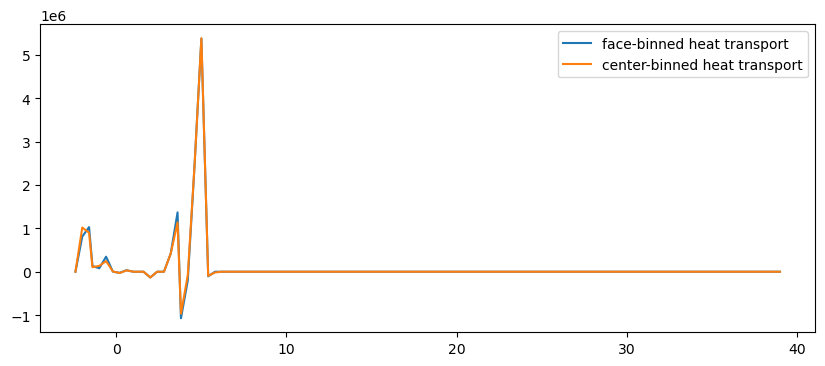

In [18]:
# plot the difference between binning at cell center vs binning at face to see this

x = boundsT.flatten()[1:-1]
fig = plt.figure()

ax = plt.subplot(111)

ax.plot(x,Msumface,label="face-binned heat transport")
ax.plot(x,Msum,label="center-binned heat transport")
ax.legend()

# does this make sense? Yes, the faces will generally be warmer than the cell center, so good.

In [19]:
# make sure we have the ADVhT term and others (same as the heat budget from the layers package)
# should just be able to copy this over from the function

In [20]:
from create_aste90_layers import create_layers_totalTHETA  # ,create_layers_totalSALT
# we will need to modify this to bin at face theta and return more than just the Msum
dt = 1800

In [21]:
Msum, dF_Tnew = create_layers_totalTHETA(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt)
# neither of these have been normalized, so we should consider this when plotting

In [22]:
np.nansum(Msum["Msum"]) # cool, now check dF_Tnew

10512990.032651436

In [23]:
dF_Tnew.shape
# make an array of term names in this
labels = np.array(["ADVh","ADVr","DFh","DFr","surf","kpp","tend"])

/tmp/ipykernel_1974987/2359172678.py:184: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


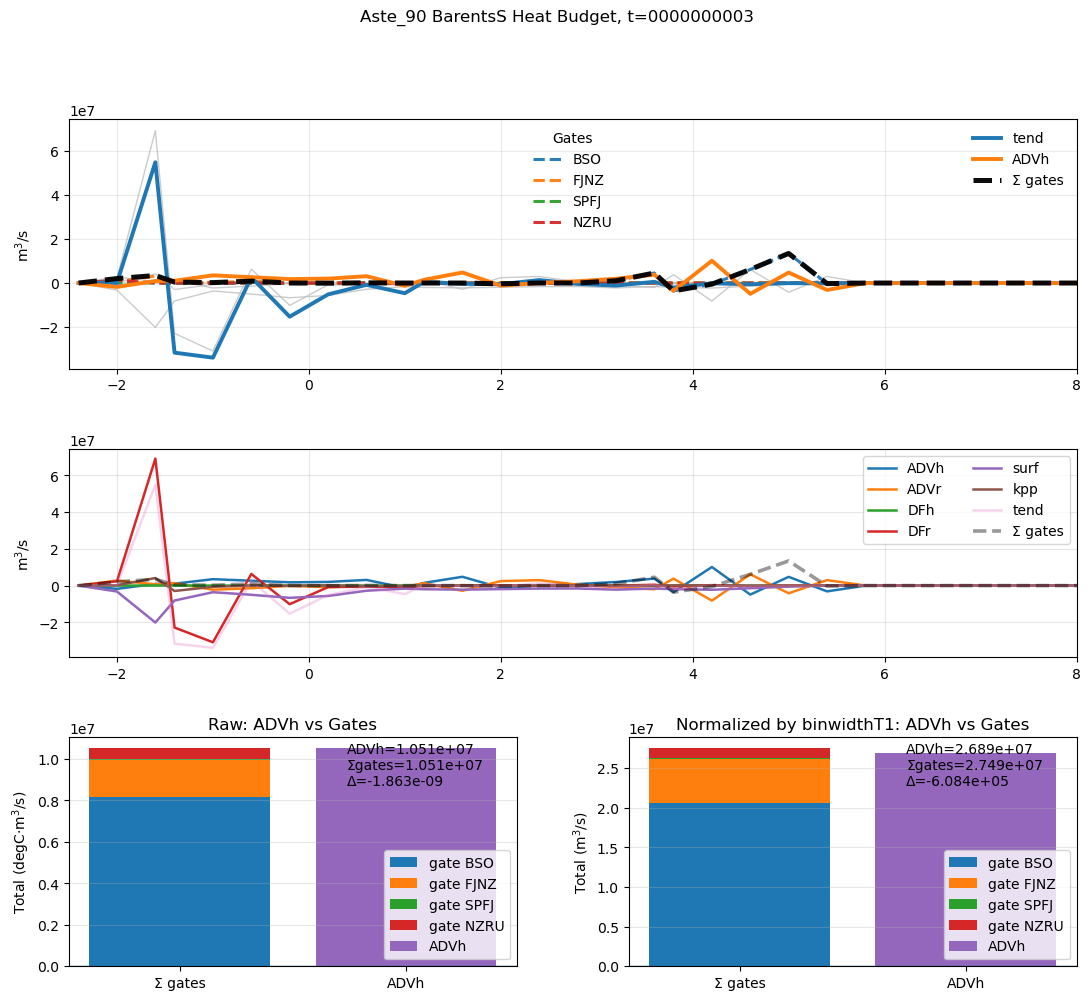

In [24]:

# ----------------------------
# helpers for the bar charts
# ----------------------------
def stacked_posneg_bar(ax, x, terms, prefix=""):
    """Single stacked bar at x from {name: value}, stacking positives up and negatives down."""
    posbottom = 0.0
    negbottom = 0.0
    for name, val in terms.items():
        v = float(np.nan_to_num(val, nan=0.0))
        lab = f"{prefix}{name}"
        if v >= 0:
            ax.bar(x, v, bottom=posbottom, label=lab)
            posbottom += v
        else:
            ax.bar(x, v, bottom=negbottom, label=lab)
            negbottom += v
    return posbottom, negbottom

def as_scalar(a):
    a = np.asarray(a)
    return float(np.nansum(a)) if a.ndim else float(a)

def plot_compare(ax, gate_totals, dF_total, ylabel, title):
    stacked_posneg_bar(ax, 0, gate_totals, prefix="gate ")
    ax.bar(1, dF_total, label="ADVh")

    ax.axhline(0, linewidth=1)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Σ gates", "ADVh"])
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3, axis="y")
    ax.set_title(title)

    sum_gates = sum(gate_totals.values())
    ax.text(
        0.62, 0.98,
        f"ADVh={dF_total:.3e}\nΣgates={sum_gates:.3e}\nΔ={dF_total - sum_gates:.3e}",
        transform=ax.transAxes, va="top"
    )

    # de-dup legend labels
    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l)
            h2.append(h); l2.append(l)
    ax.legend(h2, l2, loc="lower right")


# ------------------------------------------------------------
# Inputs assumed you already have:
#   x, dF_Tnew, labels, binwidthT1, Msum
# ------------------------------------------------------------
gate_keys = ["BSO", "FJNZ", "SPFJ", "NZRU"]
# make a single, non-repeating color cycle long enough for:
#   6 tendency lines + 4 gates + 1 gate_sum = 11 lines
tab20 = list(plt.get_cmap("tab20").colors)
tab10_like = tab20[0::2]          # take only the first of each pair -> 10 distinct hues
tab10_like += tab20[1::2]         # (optional) only used if you need >10 lines

n_total = 6 + len(gate_keys) + 1  # 6 tendency + gates + sum(gates)
ax_colors = tab10_like[:n_total]  # should cover 11 with the + tab20[1::2] fallback

fig = plt.figure(figsize=(13, 11))
gs = fig.add_gridspec(nrows=3, ncols=2, height_ratios=[1.2, 1.0, 1.1],
                      hspace=0.35, wspace=0.25)


ax1 = fig.add_subplot(gs[0, :])

# ---- pick which indices are which
i_advh = 0
i_tend = -1
advh_label = labels[i_advh]
tend_label = labels[i_tend]

# ---- compute Σ gates (binwise), then normalize
gate_sum = np.zeros_like(dF_Tnew[i_advh], dtype=float)
for k in gate_keys:
    gate_sum += np.nan_to_num(np.asarray(Msum[k]), nan=0.0)

ADVh = np.asarray(dF_Tnew[i_advh], dtype=float) / binwidthT1
TEND = np.asarray(dF_Tnew[i_tend], dtype=float) / binwidthT1
Gsum = gate_sum / binwidthT1

# ---- 1) background: all other terms (light, thin)
# (safer than range(6): uses actual number of terms)
n_terms = len(dF_Tnew)
for i in range(n_terms):
    if i in (i_advh, i_tend):
        continue
    ax1.plot(
        x, np.asarray(dF_Tnew[i], dtype=float) / binwidthT1,
        color="0.75", linewidth=1.0, alpha=0.8,
        zorder=1
    )

# ---- gates: distinct colors + separate legend
# pick a qualitative colormap and sample N colors
cmap = plt.get_cmap("tab10")  # or "tab20"
N = len(gate_keys)

gate_handles, gate_labels = [], []
for j, k in enumerate(gate_keys):
    color = cmap(j % cmap.N)  # cycles if more gates than cmap provides
    ln, = ax1.plot(
        x, np.asarray(Msum[k], dtype=float) / binwidthT1,
        linestyle="--",
        color=color,
        linewidth=2.2,
        alpha=0.95,
        zorder=2
    )
    gate_handles.append(ln)
    gate_labels.append(str(k))  # or gate_name_map[k]

# ---- 2) foreground: the 3 lines you care about
h_tend, = ax1.plot(x, TEND, label=tend_label, linewidth=2.8, zorder=4)
h_advh, = ax1.plot(x, ADVh, label=advh_label, linewidth=2.8, zorder=4)
h_gsum, = ax1.plot(
    x, Gsum, label="Σ gates",
    linestyle="--", color="k",
    linewidth=3.6, alpha=0.95, zorder=5
)

# ---- axes
ax1.set_ylabel(r"m$^3$/s")
ax1.set_xlim(-2.5, 8)
ax1.grid(alpha=0.25)

# ---- legends: main + separate gates legend
leg_main = ax1.legend(handles=[h_tend, h_advh, h_gsum],
                      loc="upper right", frameon=False)

# put gates legend somewhere that doesn't overlap (adjust loc if needed)
leg_gates = ax1.legend(gate_handles, gate_labels, title="Gates",
                       loc="upper center", frameon=False, ncol=1)

ax1.add_artist(leg_main)  # keep both legends

# --- (2) Middle: show all terms (normalized) + Σ gates, NO residuals ---
ax2 = fig.add_subplot(gs[1, :], sharex=ax1)

# plot all tendency terms (solid)
for i in range(6):
    ax2.plot(x, dF_Tnew[i] / binwidthT1, label=labels[i], linestyle='-', linewidth=1.8)

ax2.plot(x, dF_Tnew[-1] / binwidthT1, label=labels[-1], linestyle='-', linewidth=1.8,alpha=0.3)


# Σ gates (binwise), dashed + a bit thicker
gate_sum = np.zeros_like(dF_Tnew[0], dtype=float)
for k in gate_keys:
    gate_sum += np.nan_to_num(np.asarray(Msum[k]), nan=0.0)

ax2.plot(x, gate_sum / binwidthT1, label="Σ gates", linestyle="--", linewidth=2.6, color="k", alpha=0.4)

ax2.set_ylabel(r"m$^3$/s")
ax2.set_xlim(-2.5, 8)
ax2.grid(alpha=0.3)
ax2.legend(loc="best", ncol=2)

# --- (3) Bottom: bar charts (raw vs normalized) ---
axL = fig.add_subplot(gs[2, 0])
axR = fig.add_subplot(gs[2, 1])

# raw (degC*m^3/s)
gate_totals_raw = {k: as_scalar(Msum[k]) for k in gate_keys}
dF_total_raw    = as_scalar(dF_Tnew[0])

# normalized (m^3/s), bin-by-bin then summed
gate_totals_norm = {k: as_scalar(np.asarray(Msum[k]) / binwidthT1) for k in gate_keys}
dF_total_norm    = as_scalar(dF_Tnew[0] / binwidthT1)

plot_compare(axL, gate_totals_raw,  dF_total_raw,
             ylabel=r"Total (degC·m$^3$/s)", title="Raw: ADVh vs Gates")

plot_compare(axR, gate_totals_norm, dF_total_norm,
             ylabel=r"Total (m$^3$/s)",      title="Normalized by binwidthT1: ADVh vs Gates")

plt.suptitle("Aste_90 BarentsS Heat Budget, t=0000000003")
plt.tight_layout()
plt.savefig("heat_budg_miniaste_0000000003.png",dpi=300)

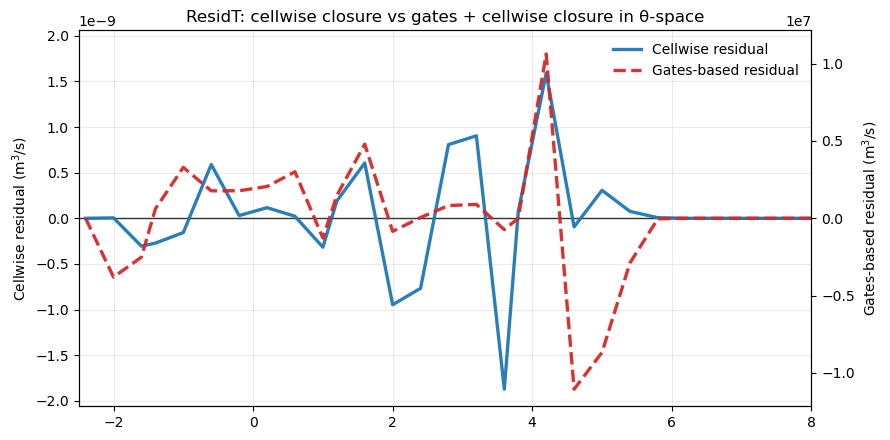

In [25]:

def center_zero_ylim(ax, y, pad=0.10):
    m = float(np.nanmax(np.abs(y)))
    if not np.isfinite(m) or m == 0:
        m = 1.0
    m *= (1 + pad)
    ax.set_ylim(-m, m)

fig = plt.figure(figsize=(9, 4.5))
axL = plt.subplot(111)

# normalized terms
TEND    = dF_Tnew[-1] / binwidthT1
SUM_ALL = np.nansum(dF_Tnew[:-1], axis=0) / binwidthT1
OTHER   = np.nansum(dF_Tnew[1:-1], axis=0) / binwidthT1
GATES   = np.asarray(Msum["Msum"]) / binwidthT1

# residuals
res_cell  = (TEND - SUM_ALL)/1e3
res_gates = TEND - (OTHER + GATES)

# left axis: cellwise residual
axL.axhline(0, color="0.2", lw=1)
l1, = axL.plot(x, res_cell, lw=2.4, color="C0", alpha=0.95,
               label="Cellwise residual")
axL.set_ylabel(r"Cellwise residual (m$^3$/s)")
axL.set_xlim(-2.5, 8)
axL.grid(alpha=0.25)
center_zero_ylim(axL, res_cell)

# right axis: gates-based residual
axR = axL.twinx()
l2, = axR.plot(x, res_gates, lw=2.4, color="C3", alpha=0.95, linestyle="--",
               label="Gates-based residual")
axR.set_ylabel(r"Gates-based residual (m$^3$/s)")
center_zero_ylim(axR, res_gates)

# combined legend
axL.legend([l1, l2], [l1.get_label(), l2.get_label()],
           loc="best", frameon=False)

axL.set_title("ResidT: cellwise closure vs gates + cellwise closure in θ-space")
plt.tight_layout()

plt.savefig("heat_resid_miniaste_0000000003.png",dpi=300)

## Now do the same thing with SALT

In [26]:
# we need to go through and fix the function which binned by face tracer value
from create_aste90_layers import create_layers_totalSALT

In [27]:
MsumS, dF_Snew = create_layers_totalSALT(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt)


In [28]:
print(np.nansum(dF_Snew[0]))

print(MsumS["Msum"].sum())

# great, these are the same in units of PSU.m^3/s

-1871868.8170449866
-1871868.8170450125


/tmp/ipykernel_1974987/1354636334.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


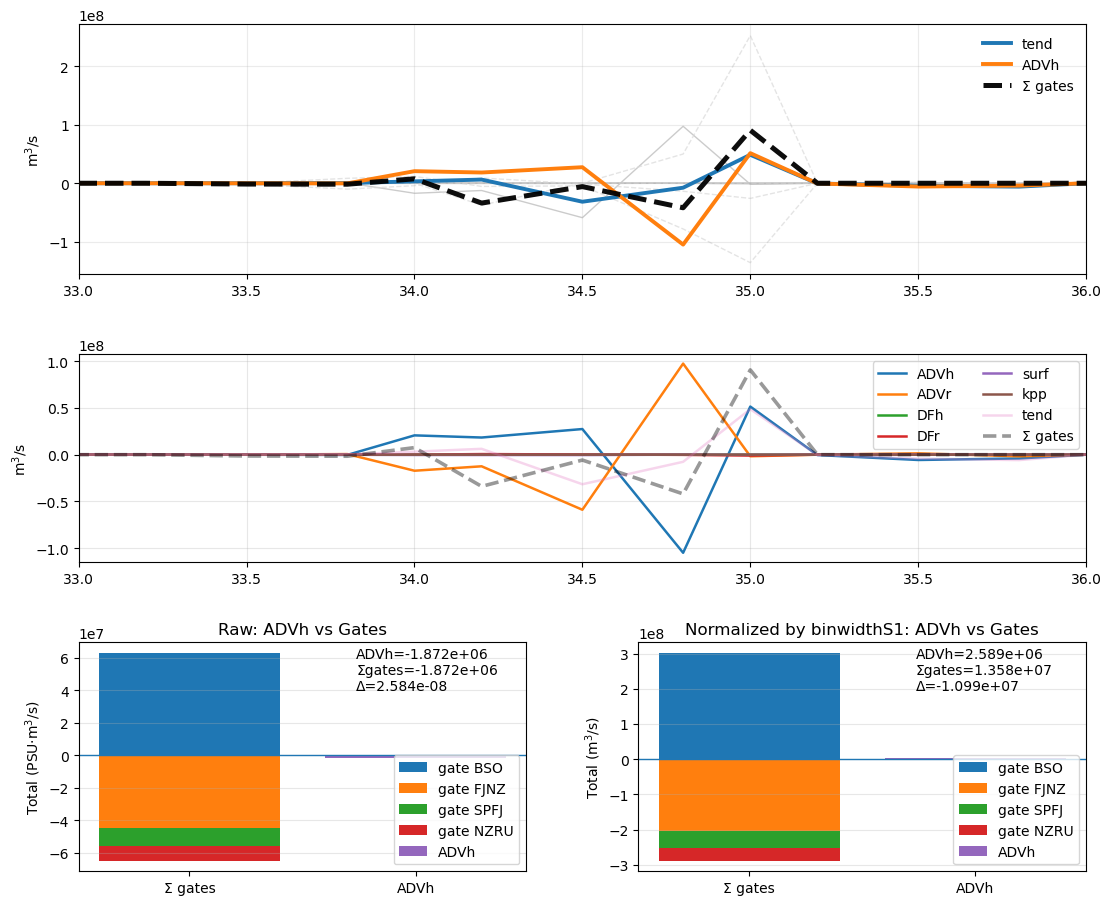

In [29]:
x = boundsS.flatten()[1:-1]
# ------------------------------------------------------------
# Inputs assumed you already have:
#   x, dF_Snew, labels, binwidthS1, MsumS
# ------------------------------------------------------------
gate_keys = ["BSO", "FJNZ", "SPFJ", "NZRU"]
# make a single, non-repeating color cycle long enough for:
#   6 tendency lines + 4 gates + 1 gate_sum = 11 lines
tab20 = list(plt.get_cmap("tab20").colors)
tab10_like = tab20[0::2]          # take only the first of each pair -> 10 distinct hues
tab10_like += tab20[1::2]         # (optional) only used if you need >10 lines

n_total = 6 + len(gate_keys) + 1  # 6 tendency + gates + sum(gates)
ax_colors = tab10_like[:n_total]  # should cover 11 with the + tab20[1::2] fallback

fig = plt.figure(figsize=(13, 11))
gs = fig.add_gridspec(nrows=3, ncols=2, height_ratios=[1.2, 1.0, 1.1],
                      hspace=0.35, wspace=0.25)


ax1 = fig.add_subplot(gs[0, :])

# ---- pick which indices are which
# adjust these to match your labels ordering
i_advh = 0                          # e.g. ADVh is dF_Snew[0]
i_tend = -1                         # tendency is last in your earlier code
advh_label = labels[i_advh]
tend_label = labels[i_tend]

# ---- compute Σ gates (binwise), then normalize
gate_sum = np.zeros_like(dF_Snew[0], dtype=float)
for k in gate_keys:
    gate_sum += np.nan_to_num(np.asarray(MsumS[k]), nan=0.0)

ADVh = dF_Snew[i_advh] / binwidthS1
TEND = dF_Snew[i_tend] / binwidthS1
Gsum = gate_sum / binwidthS1

# ---- 1) background: all other terms (light, thin)
for i in range(6):
    if i in (i_advh, i_tend):
        continue
    ax1.plot(
        x, dF_Snew[i] / binwidthS1,
        color="0.75", linewidth=1.0, alpha=0.8,
        zorder=1
    )

# optional: individual gates as background (even lighter dashed)
for k in gate_keys:
    ax1.plot(
        x, np.asarray(MsumS[k]) / binwidthS1,
        color="0.85", linestyle="--", linewidth=1.0, alpha=0.7,
        zorder=1
    )

# ---- 2) foreground: the 3 lines you care about
ax1.plot(x, TEND, label=tend_label, linewidth=2.8, zorder=4)                 # solid
ax1.plot(x, ADVh, label=advh_label, linewidth=2.8, zorder=4)                 # solid
ax1.plot(x, Gsum, label="Σ gates", linestyle="--", color="k",
         linewidth=3.6, alpha=0.95, zorder=5)                                # emphasized

# ---- axes/legend
ax1.set_ylabel(r"m$^3$/s")
ax1.set_xlim(33, 36)
ax1.grid(alpha=0.25)

# legend only for the highlighted lines
ax1.legend(loc="best", frameon=False)

# --- (2) Middle: show all terms (normalized) + Σ gates, NO residuals ---
ax2 = fig.add_subplot(gs[1, :], sharex=ax1)

# plot all tendency terms (solid)
for i in range(6):
    ax2.plot(x, dF_Snew[i] / binwidthS1, label=labels[i], linestyle='-', linewidth=1.8)

ax2.plot(x, dF_Snew[-1] / binwidthS1, label=labels[-1], linestyle='-', linewidth=1.8,alpha=0.3)


# Σ gates (binwise), dashed + a bit thicker
gate_sum = np.zeros_like(dF_Snew[0], dtype=float)
for k in gate_keys:
    gate_sum += np.nan_to_num(np.asarray(MsumS[k]), nan=0.0)

ax2.plot(x, gate_sum / binwidthS1, label="Σ gates", linestyle="--", linewidth=2.6, color="k", alpha=0.4)

ax2.set_ylabel(r"m$^3$/s")
ax2.set_xlim(33, 36)
ax2.grid(alpha=0.3)
ax2.legend(loc="best", ncol=2)

# --- (3) Bottom: bar charts (raw vs normalized) ---
axL = fig.add_subplot(gs[2, 0])
axR = fig.add_subplot(gs[2, 1])

# raw (degC*m^3/s)
gate_totals_raw = {k: as_scalar(MsumS[k]) for k in gate_keys}
dF_total_raw    = as_scalar(dF_Snew[0])

# normalized (m^3/s), bin-by-bin then summed
gate_totals_norm = {k: as_scalar(np.asarray(MsumS[k]) / binwidthS1) for k in gate_keys}
dF_total_norm    = as_scalar(dF_Snew[0] / binwidthS1)

plot_compare(axL, gate_totals_raw,  dF_total_raw,
             ylabel=r"Total (PSU·m$^3$/s)", title="Raw: ADVh vs Gates")

plot_compare(axR, gate_totals_norm, dF_total_norm,
             ylabel=r"Total (m$^3$/s)",      title="Normalized by binwidthS1: ADVh vs Gates")

plt.tight_layout()


/tmp/ipykernel_1974987/3102042924.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


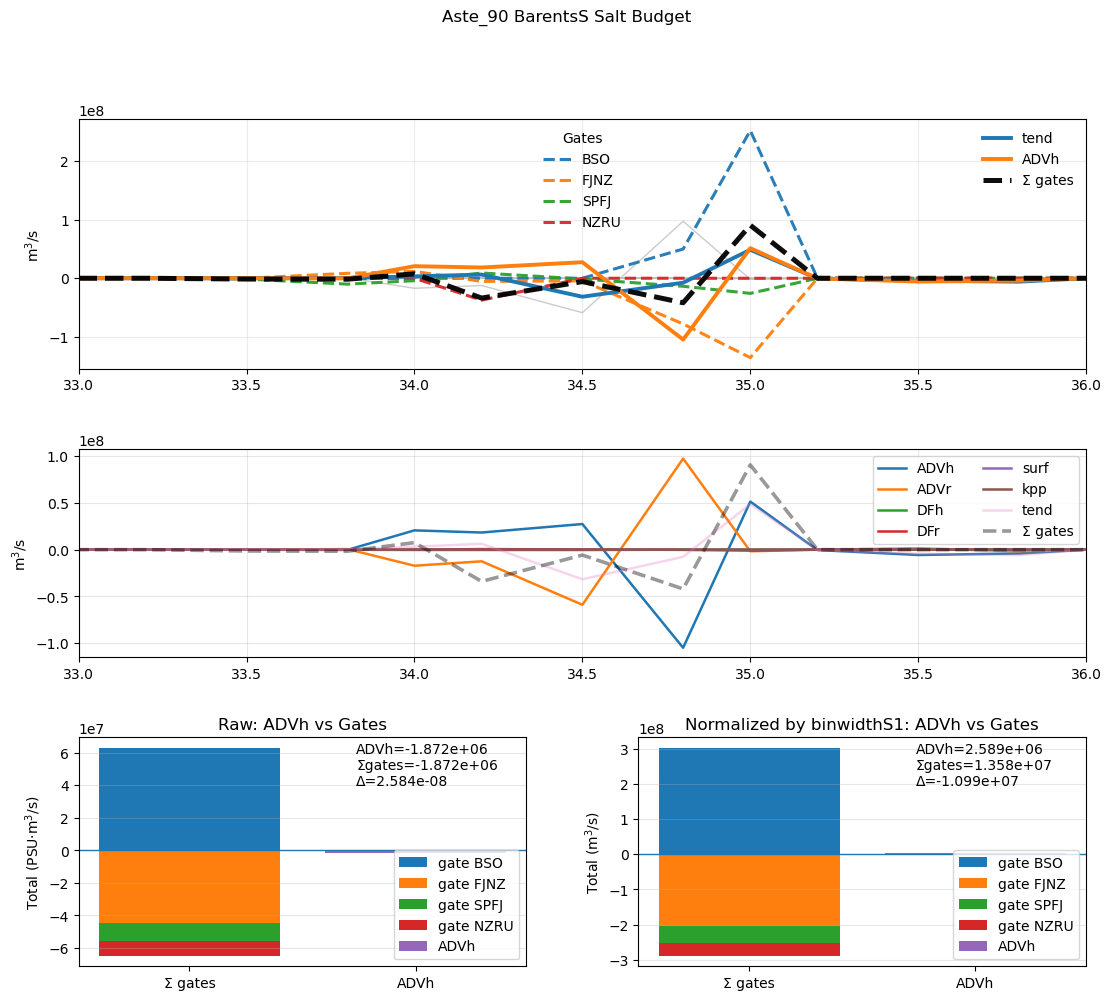

In [30]:
# ------------------------------------------------------------
# SALT BUDGET (same styling / gate colors as your THETA plot)
# ------------------------------------------------------------

# x from salt bin bounds (your line)
x = boundsS.flatten()[1:-1]

gate_keys = ["BSO", "FJNZ", "SPFJ", "NZRU"]

# --- IMPORTANT: reuse EXACT same gate colormap mapping as theta
# tab10 gives 4 distinct colors; use consistent gate->color mapping
cmap_g = plt.get_cmap("tab10")
gate_color = {k: cmap_g(i) for i, k in enumerate(gate_keys)}  # BSO=0, FJNZ=1, SPFJ=2, NZRU=3

fig = plt.figure(figsize=(13, 11))
gs = fig.add_gridspec(nrows=3, ncols=2, height_ratios=[1.2, 1.0, 1.1],
                      hspace=0.35, wspace=0.25)

# -----------------
# (1) TOP: highlight TEND, ADVh, Σ gates + separate gates legend
# -----------------
ax1 = fig.add_subplot(gs[0, :])

i_advh = 0
i_tend = -1
advh_label = labels[i_advh]
tend_label = labels[i_tend]

# Σ gates (binwise) then normalize
gate_sum = np.zeros_like(dF_Snew[i_advh], dtype=float)
for k in gate_keys:
    gate_sum += np.nan_to_num(np.asarray(MsumS[k]), nan=0.0)

ADVh = np.asarray(dF_Snew[i_advh], dtype=float) / binwidthS1
TEND = np.asarray(dF_Snew[i_tend], dtype=float) / binwidthS1
Gsum = gate_sum / binwidthS1

# background other terms
n_terms = len(dF_Snew)
for i in range(n_terms):
    if i in (i_advh, i_tend):
        continue
    ax1.plot(x, np.asarray(dF_Snew[i], dtype=float) / binwidthS1,
             color="0.75", linewidth=1.0, alpha=0.8, zorder=1)

# gates (colored dashed) + separate legend
gate_handles, gate_labels = [], []
for k in gate_keys:
    ln, = ax1.plot(
        x, np.asarray(MsumS[k], dtype=float) / binwidthS1,
        linestyle="--",
        color=gate_color[k],
        linewidth=2.2,
        alpha=0.95,
        zorder=2
    )
    gate_handles.append(ln)
    gate_labels.append(k)

# foreground 3 lines
h_tend, = ax1.plot(x, TEND, label=tend_label, linewidth=2.8, zorder=4)
h_advh, = ax1.plot(x, ADVh, label=advh_label, linewidth=2.8, zorder=4)
h_gsum, = ax1.plot(x, Gsum, label="Σ gates", linestyle="--", color="k",
                   linewidth=3.6, alpha=0.95, zorder=5)

ax1.set_ylabel(r"m$^3$/s")
ax1.set_xlim(33, 36)
ax1.grid(alpha=0.25)

leg_main = ax1.legend(handles=[h_tend, h_advh, h_gsum],
                      loc="upper right", frameon=False)
leg_gates = ax1.legend(gate_handles, gate_labels, title="Gates",
                       loc="upper center", frameon=False, ncol=1)
ax1.add_artist(leg_main)

# -----------------
# (2) MIDDLE: all terms normalized + Σ gates
# -----------------
ax2 = fig.add_subplot(gs[1, :], sharex=ax1)

# plot all terms (solid); keep same as your theta version
for i in range(min(6, len(dF_Snew))):
    ax2.plot(x, np.asarray(dF_Snew[i], dtype=float) / binwidthS1,
             label=labels[i], linestyle="-", linewidth=1.8)

# tendency (last) light
ax2.plot(x, np.asarray(dF_Snew[-1], dtype=float) / binwidthS1,
         label=labels[-1], linestyle="-", linewidth=1.8, alpha=0.3)

# Σ gates
gate_sum = np.zeros_like(dF_Snew[i_advh], dtype=float)
for k in gate_keys:
    gate_sum += np.nan_to_num(np.asarray(MsumS[k]), nan=0.0)
ax2.plot(x, gate_sum / binwidthS1, label="Σ gates",
         linestyle="--", linewidth=2.6, color="k", alpha=0.4)

ax2.set_ylabel(r"m$^3$/s")
ax2.set_xlim(33, 36)
ax2.grid(alpha=0.3)
ax2.legend(loc="best", ncol=2)

# -----------------
# (3) BOTTOM: bar charts (raw vs normalized)
# -----------------
axL = fig.add_subplot(gs[2, 0])
axR = fig.add_subplot(gs[2, 1])

# raw (PSU*m^3/s)
gate_totals_raw = {k: as_scalar(MsumS[k]) for k in gate_keys}
dF_total_raw    = as_scalar(dF_Snew[i_advh])

# normalized (m^3/s)
gate_totals_norm = {k: as_scalar(np.asarray(MsumS[k]) / binwidthS1) for k in gate_keys}
dF_total_norm    = as_scalar(np.asarray(dF_Snew[i_advh]) / binwidthS1)

plot_compare(axL, gate_totals_raw, dF_total_raw,
             ylabel=r"Total (PSU·m$^3$/s)", title="Raw: ADVh vs Gates")

plot_compare(axR, gate_totals_norm, dF_total_norm,
             ylabel=r"Total (m$^3$/s)", title="Normalized by binwidthS1: ADVh vs Gates")

plt.suptitle("Aste_90 BarentsS Salt Budget")
plt.tight_layout()
plt.savefig("salt_budg_miniaste_0000000003.png", dpi=300)

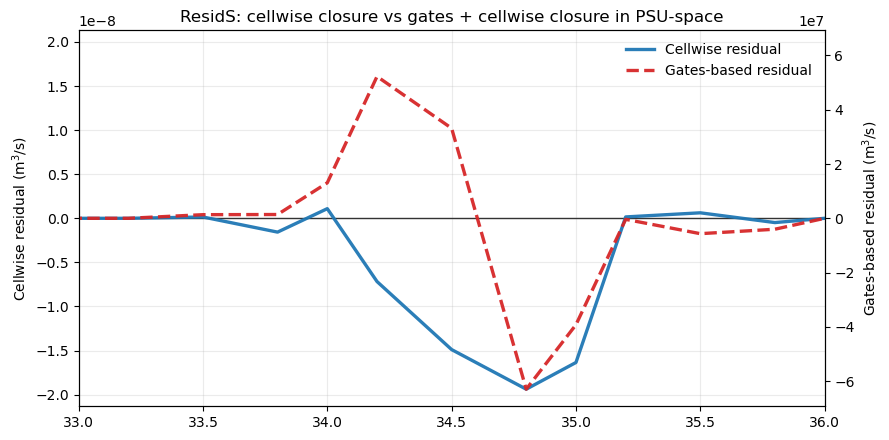

In [49]:

def center_zero_ylim(ax, y, pad=0.10):
    m = float(np.nanmax(np.abs(y)))
    if not np.isfinite(m) or m == 0:
        m = 1.0
    m *= (1 + pad)
    ax.set_ylim(-m, m)

fig = plt.figure(figsize=(9, 4.5))
axL = plt.subplot(111)

# normalized terms
TEND    = dF_Snew[-1] / binwidthS1
SUM_ALL = np.nansum(dF_Snew[:-1], axis=0) / binwidthS1
OTHER   = np.nansum(dF_Snew[1:-1], axis=0) / binwidthS1
GATES   = np.asarray(MsumS["Msum"]) / binwidthS1

# residuals
res_cell  = (TEND - SUM_ALL)/1e3
res_gates = TEND - (OTHER + GATES)

# left axis: cellwise residual
axL.axhline(0, color="0.2", lw=1)
l1, = axL.plot(x, res_cell, lw=2.4, color="C0", alpha=0.95,
               label="Cellwise residual")
axL.set_ylabel(r"Cellwise residual (m$^3$/s)")
axL.set_xlim(33, 36)
axL.grid(alpha=0.25)
center_zero_ylim(axL, res_cell)

# right axis: gates-based residual
axR = axL.twinx()
l2, = axR.plot(x, res_gates, lw=2.4, color="C3", alpha=0.95, linestyle="--",
               label="Gates-based residual")
axR.set_ylabel(r"Gates-based residual (m$^3$/s)")
center_zero_ylim(axR, res_gates)

# combined legend
axL.legend([l1, l2], [l1.get_label(), l2.get_label()],
           loc="best", frameon=False)

axL.set_title("ResidS: cellwise closure vs gates + cellwise closure in PSU-space")
plt.tight_layout()